# Assignment Day 38 - Hyperparameter Tuning with Python
Student: **Daud Rusyad Nurdin**, *bootcamp DA/DS 34*

Pada tugas ini akan dilakukan pengujian terhadap model machine learning untuk memprediksi pelanggan yang akan berhenti menggunakan layanan (churn) sehingga tim marketing dapat memberikan tindakan-tindakan (seperti melakukan promo, memberikan insentif, point dan tidakan marketing lainnya) untuk menjaga pelanggan dari churn (program retensi).

## Import libraries

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score, ConfusionMatrixDisplay

sns.set_style("whitegrid")

## Import Dataset
* churn.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True) # add command: ", force_remount=True" to avoid warning

# here is my data stored...
data_path = '/content/drive/My Drive/Dibimbing/Day 38 - Hyperparameter Tuning in Python/'

Mounted at /content/drive/


In [ ]:
# load datasets
df_churn = pd.read_csv(data_path + 'churn.csv')
df_churn.head()

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0.0,NaN,No,1.0,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0.0,No,No,34.0,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0.0,No,No,2.0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0.0,No,No,45.0,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0.0,No,No,2.0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##Exploratory Data Analysis

In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7046 entries, 0 to 7045
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7037 non-null   object 
 1   Gender            7030 non-null   object 
 2   SeniorCitizen     7034 non-null   float64
 3   Partner           7030 non-null   object 
 4   Dependents        7027 non-null   object 
 5   Tenure            7029 non-null   float64
 6   Contract          7033 non-null   object 
 7   PaperlessBilling  7033 non-null   object 
 8   PaymentMethod     7035 non-null   object 
 9   MonthlyCharges    7036 non-null   float64
 10  TotalCharges      7046 non-null   float64
 11  Churn             7046 non-null   object 
dtypes: float64(4), object(8)
memory usage: 660.7+ KB


In [ ]:
df_churn.describe()

,SeniorCitizen,Tenure,MonthlyCharges,TotalCharges
count,7034.000000,7029.000000,7036.000000,7046.000000
mean,0.162354,32.412150,64.800391,2281.921636
std,0.368802,24.546806,30.070620,2265.653438
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.650000,401.350000
50%,0.000000,29.000000,70.350000,1397.100000
75%,0.000000,55.000000,89.850000,3791.000000
max,1.000000,72.000000,118.750000,8684.800000


###Check missing values

In [ ]:
x_cols_null = df_churn.isnull().sum()
cols_null = x_cols_null[x_cols_null > 0].index.tolist()
x_cols_null

,0
customerID,9
Gender,16
SeniorCitizen,12
Partner,16
Dependents,19
Tenure,17
Contract,13
PaperlessBilling,13
PaymentMethod,11
MonthlyCharges,10


In [ ]:
# Periksa data dengan missing value di CustomerID
df_churn[df_churn['customerID'].isna()]

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
194,NaN,Male,0.0,Yes,Yes,59.0,Two year,No,Credit card (automatic),19.30,1192.70,No
1349,NaN,Female,0.0,No,No,18.0,Month-to-month,Yes,Electronic check,88.35,1639.30,Yes
1634,NaN,Male,1.0,No,No,17.0,Month-to-month,Yes,Electronic check,45.05,770.60,Yes
1771,NaN,Male,1.0,Yes,No,72.0,Two year,Yes,Bank transfer (automatic),25.00,1802.55,No
2473,NaN,Male,0.0,No,No,4.0,Month-to-month,No,Mailed check,44.55,220.75,No
2605,NaN,Female,0.0,No,Yes,39.0,Month-to-month,No,Credit card (automatic),30.10,1131.30,Yes
4088,NaN,Male,0.0,No,No,3.0,Month-to-month,Yes,Mailed check,82.30,214.40,No
4287,NaN,Female,0.0,No,No,12.0,One year,Yes,Credit card (automatic),85.15,979.05,No
5358,NaN,Female,0.0,Yes,Yes,65.0,Two year,Yes,Bank transfer (automatic),82.50,5215.10,No


Catatan:
* Terdapat nilai NULL di customerID, tetapi nantinya kolom ini akan dihapus karena tidak relevan untuk learning.

In [ ]:
# Check nilai SenionCitizen, kategorikal yang bertipe float.
df_churn['SeniorCitizen'].astype('str').value_counts()

,count
SeniorCitizen,
0.0,5892
1.0,1142
nan,12


###Check duplicate data

In [ ]:
# Check duplicate data
v_dupl = df_churn.duplicated().sum()
print(f"Total duplicate: {v_dupl}")

Total duplicate: 14


In [ ]:
# Check rows duplicate
df_churn[df_churn.duplicated()]

,customerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7032,2905-KFQUV,Female,0.0,Yes,No,2.0,Month-to-month,Yes,Credit card (automatic),70.40,154.80,No
7033,9253-QXKBE,Male,1.0,Yes,No,29.0,Month-to-month,Yes,Electronic check,94.45,2653.65,Yes
7034,6418-HNFED,Male,0.0,Yes,No,51.0,Two year,Yes,Credit card (automatic),83.25,4089.45,No
7035,4795-UXVCJ,Male,0.0,No,No,26.0,One year,No,Credit card (automatic),19.80,457.30,No
7036,3606-SBKRY,Male,0.0,No,No,31.0,One year,Yes,Electronic check,50.05,1523.40,No
7037,5233-GEEAX,Male,1.0,No,No,8.0,Month-to-month,Yes,Electronic check,29.40,221.90,Yes
7038,6000-UKLWI,Male,0.0,No,No,41.0,Two year,No,Mailed check,20.15,802.35,No
7039,2236-HILPA,Male,0.0,Yes,Yes,62.0,Two year,No,Credit card (automatic),20.65,1218.45,No
7040,2342-CKIAO,Female,0.0,No,No,2.0,Month-to-month,No,Mailed check,20.30,41.20,No
7041,5067-WJEUN,NaN,0.0,Yes,Yes,67.0,Two year,Yes,Bank transfer (automatic),54.20,3838.20,No


Catatan:
* Data duplikat akan dihapus.

###Check unique value

In [ ]:
# ambil kolom kategorikal -- kecuali customerID karena akan dibuang
cols = df_churn.columns[(df_churn.dtypes == 'object') & (df_churn.columns != 'customerID')]

for col in cols:
  print(f"Column name: {col}, #Unique: {df_churn[col].nunique()}")
  print(f"{df_churn[col].value_counts()}")
  print(f"-"*40)
  print(f"\n")

Column name: Gender, #Unique: 2
Gender
Male      3552
Female    3478
Name: count, dtype: int64
----------------------------------------


Column name: Partner, #Unique: 2
Partner
No     3638
Yes    3392
Name: count, dtype: int64
----------------------------------------


Column name: Dependents, #Unique: 2
Dependents
No     4931
Yes    2096
Name: count, dtype: int64
----------------------------------------


Column name: Contract, #Unique: 3
Contract
Month-to-month    3873
Two year          1689
One year          1471
Name: count, dtype: int64
----------------------------------------


Column name: PaperlessBilling, #Unique: 2
PaperlessBilling
Yes    4168
No     2865
Name: count, dtype: int64
----------------------------------------


Column name: PaymentMethod, #Unique: 4
PaymentMethod
Electronic check             2367
Mailed check                 1604
Bank transfer (automatic)    1540
Credit card (automatic)      1524
Name: count, dtype: int64
----------------------------------------

###Plotting data distribution and outliers

In [ ]:
# Coding kak Kurnia yang telah ditambahkan dengan boxplot vs churn
def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(20, 4))

    # histogram
    plt.subplot(1, 4, 1)
    sns.histplot(df[variable], bins=30)
    plt.title('Histogram')

    # plot Q-Q
    plt.subplot(1, 4, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.ylabel('Variable quantiles')

    # box plot
    plt.subplot(1, 4, 3)
    sns.boxplot(y=df[variable])
    plt.title('Boxplot')

    # added by Daud, 13/09/2025
    # Boxplot berdasarkan grup (e.g., Churn vs Tidak)
    plt.subplot(1, 4, 4)
    sns.boxplot(data=df, x='Churn', y=variable)
    plt.title(f'{variable} vs Churn')

    plt.show()

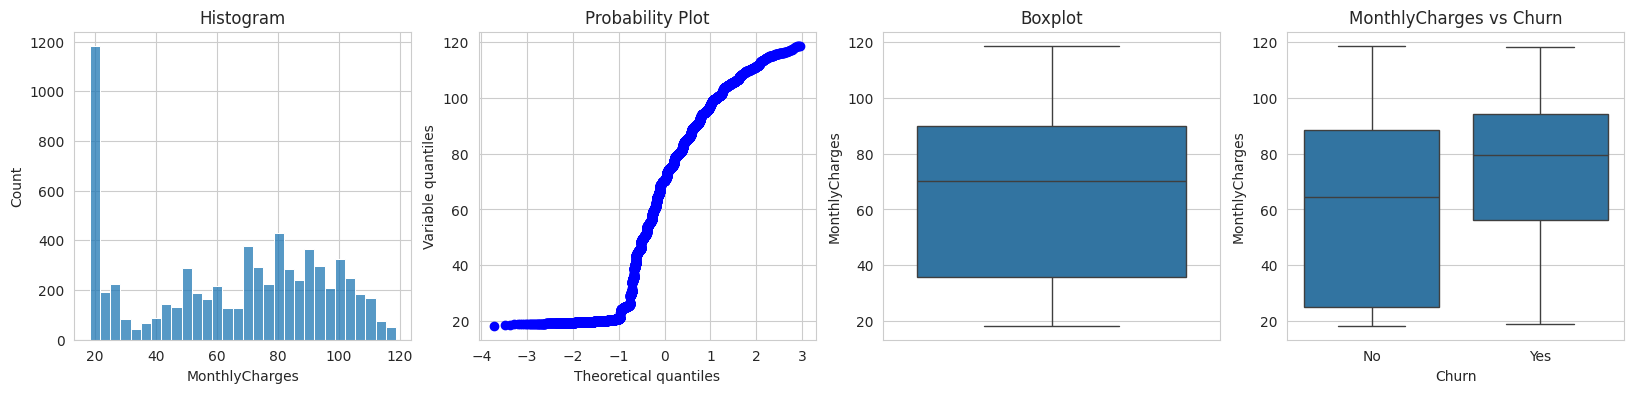

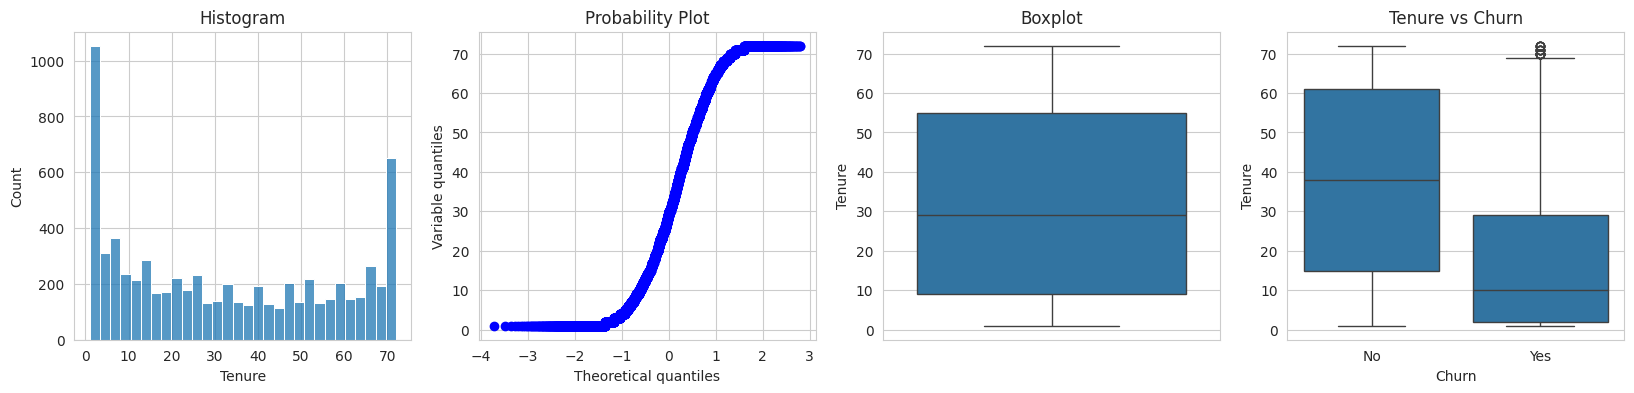

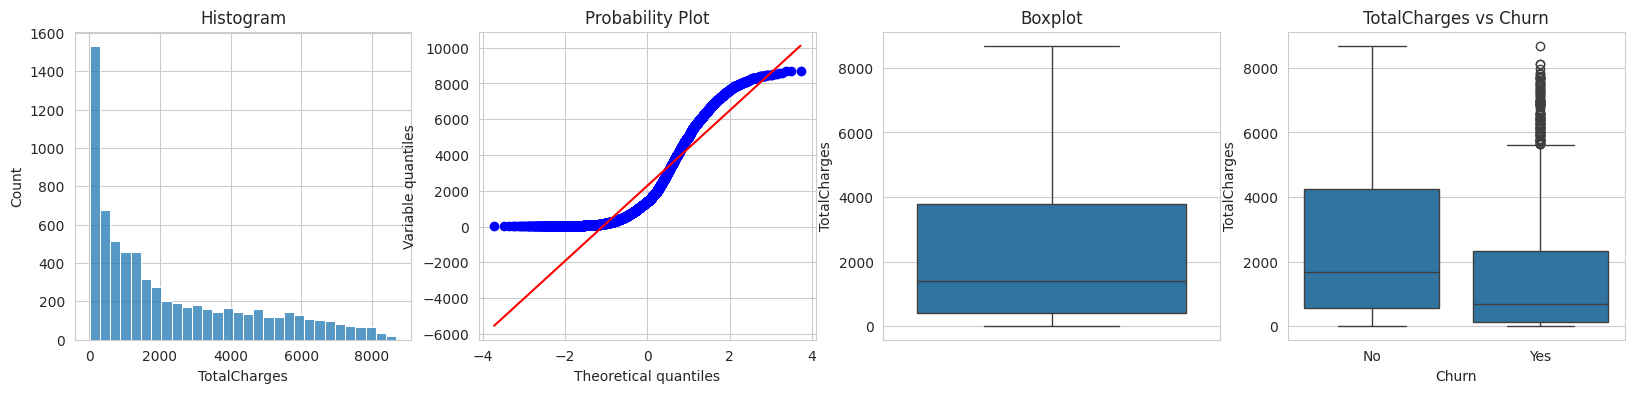

In [ ]:
cols_num = df_churn.select_dtypes(include=[np.number]).columns
cols_num = cols_num.difference(['SeniorCitizen'])

for col in cols_num:
  check_plot(df_churn, col)

###Check existence of outliers @numerical cols

In [ ]:
def ck_outliers (df, col):
  # Hitung IQR untuk kolom numerik
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  # Tentukan batas outlier
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Cari data yang outlier
  outliers = df_churn[(df_churn[col] < lower_bound) | (df_churn[col] > upper_bound)]
  print(f"Jumlah outliers di {col}: {len(outliers)}")

In [ ]:
# Call function to check outliers existence
for col in cols_num:
  ck_outliers(df_churn, col)

Jumlah outliers di MonthlyCharges: 0
Jumlah outliers di Tenure: 0
Jumlah outliers di TotalCharges: 0


Catatan:
* **Tidak ada outliers di kolom-kolom yang dicari.**

###Check categorical by churn
* Mencari relevansi churn dan informasi kategorikal

In [ ]:
def plot_categ (df, col, ix):
  plt.figure(figsize=(20, 4))
  plt.subplot(1, 3, ix)
  sns.countplot(data=df, x=col, hue='Churn')
  plt.title(col)
  plt.show()

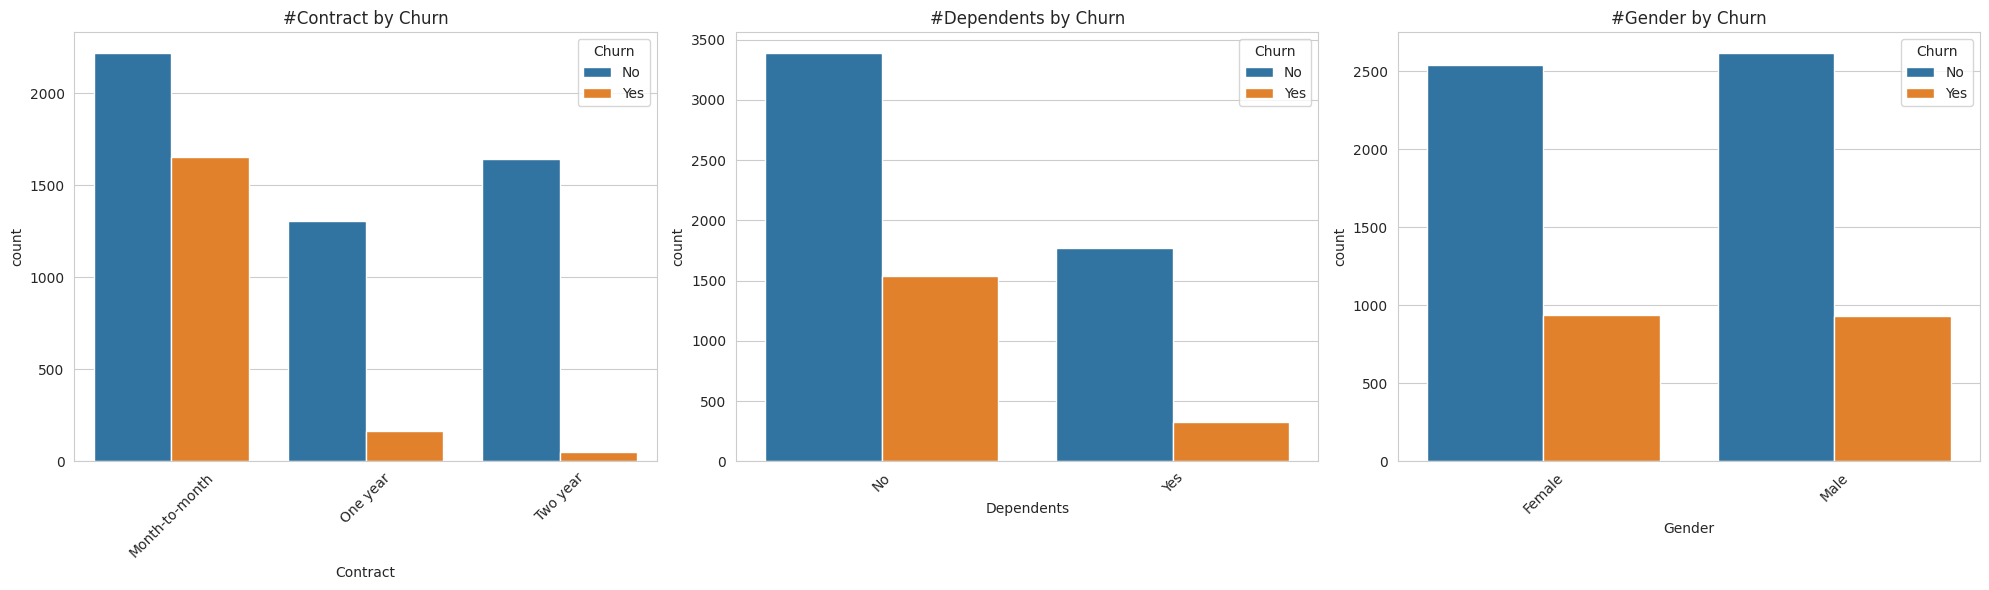

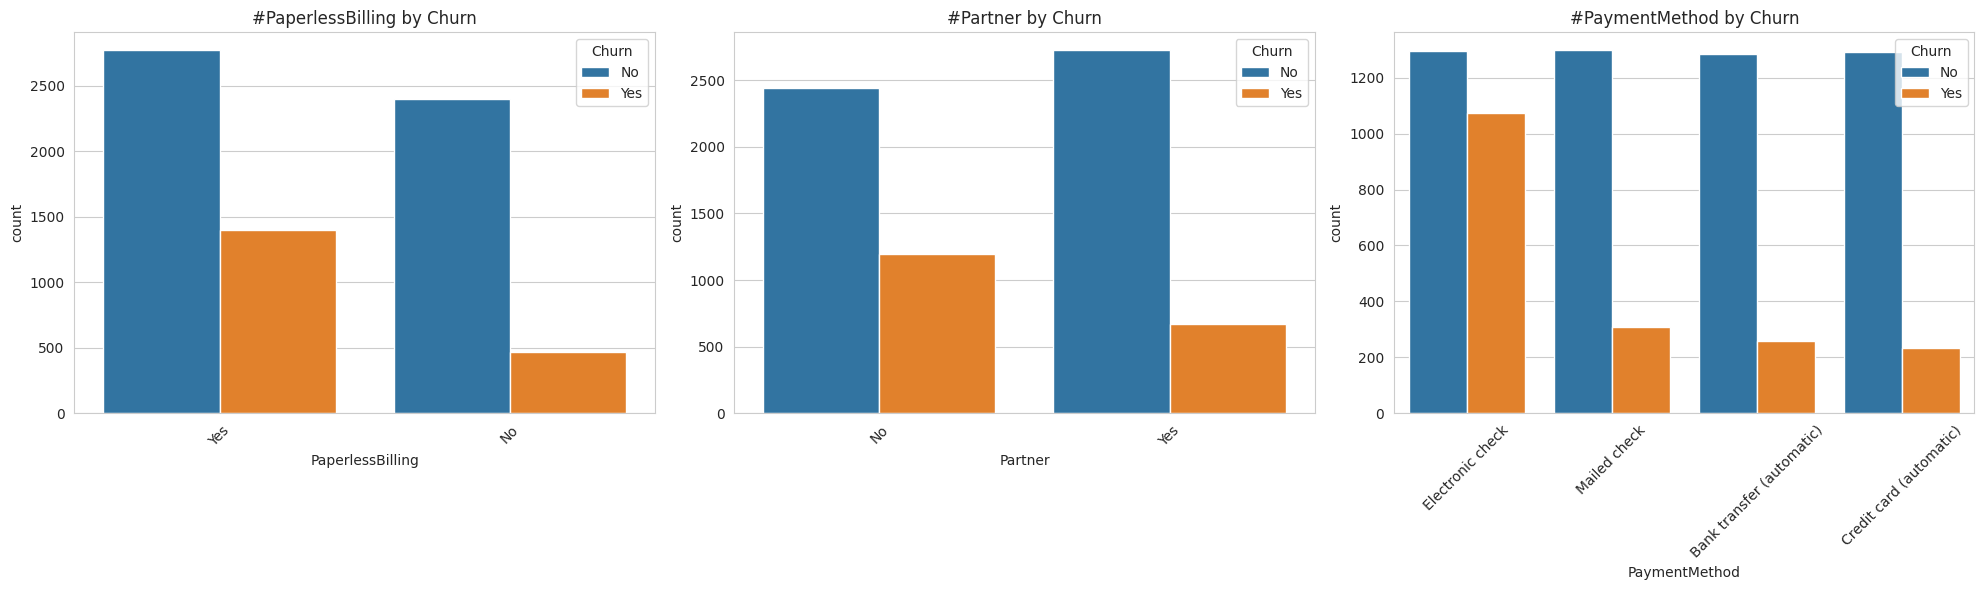

In [ ]:
cols_cat = df_churn.select_dtypes(include=['object']).columns
cols_cat = cols_cat.difference(['customerID', 'Churn'])

#Hitung berapa banyak "page" yang dibutuhkan (setiap page 3 plots)
num_pages = (len(cols_cat) + 2) // 3  # Pembulatan ke atas

for page in range(num_pages):
    # Buat figure baru untuk setiap "page" (3 plots)
    plt.figure(figsize=(20, 6))

    # Ambil 3 kolom untuk page ini
    start_idx = page * 3
    end_idx = min((page + 1) * 3, len(cols_cat))
    cols_for_page = cols_cat[start_idx:end_idx]

    # Plot 3 kolom dalam 1 baris
    for i, col in enumerate(cols_for_page, 1):
        plt.subplot(1, 3, i)
        sns.countplot(data=df_churn, x=col, hue='Churn')
        plt.title(f'#{col} by Churn')
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

Catatan:
* Pelanggan dengan contract sebentar cenderung churn, demikian juga pelanggan single, dan pengguna elekronik check.
* Dari diagram di atas tidak menunjukkan bahwa gender tertentu berpengaruh terhadap churn.

###Check total churn/unchurn and its proportion

In [ ]:
churn_counts = df_churn['Churn'].value_counts()
churn_counts

,count
Churn,
No,5174
Yes,1872


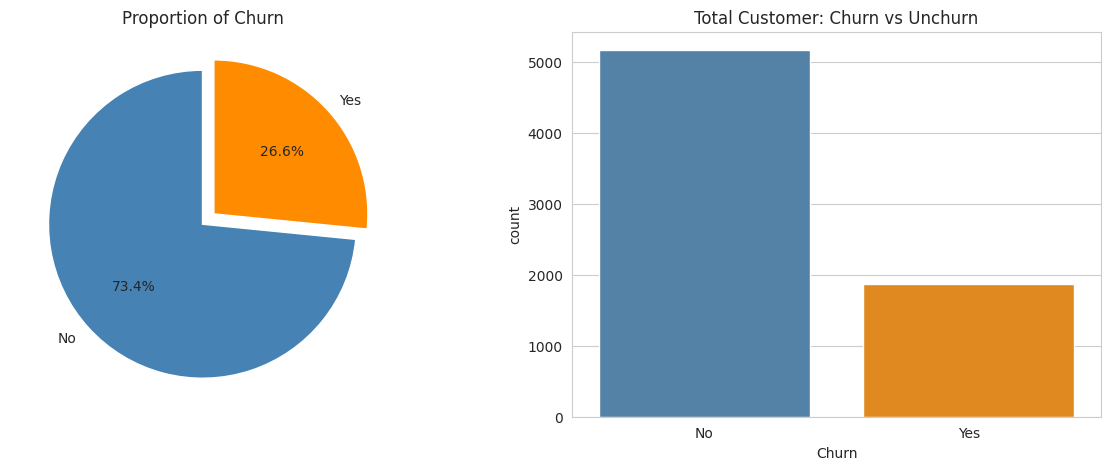

In [ ]:
plt.figure(figsize=(15, 5))

# Pie chart untuk melihat proporsi Churn
churn_counts = df_churn['Churn'].value_counts()
colors_churn = ['steelblue', 'darkorange']

explode_values = [0, 0.1]  # [No, Yes]

# Define custom colors
plt.subplot(1, 2, 1)
plt.pie(churn_counts,
        labels=churn_counts.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=explode_values,
        colors=colors_churn)

plt.title('Proportion of Churn')

# Plot jumlah pelanggan yang Churn vs Tidak
color_mapping = {'Yes': 'darkorange', 'No': 'steelblue'}

plt.subplot(1, 2, 2)
sns.countplot(data=df_churn, x='Churn', palette=[color_mapping[x] for x in df_churn['Churn'].value_counts().index])
plt.title('Total Customer: Churn vs Unchurn')
plt.show()



Catatan:
* Data imbalance --> memang "nature"-nya seperti ini untuk case: Churn, dan Churn seharusnya lebih sedikit dari Unchurn.

###Check features correlation

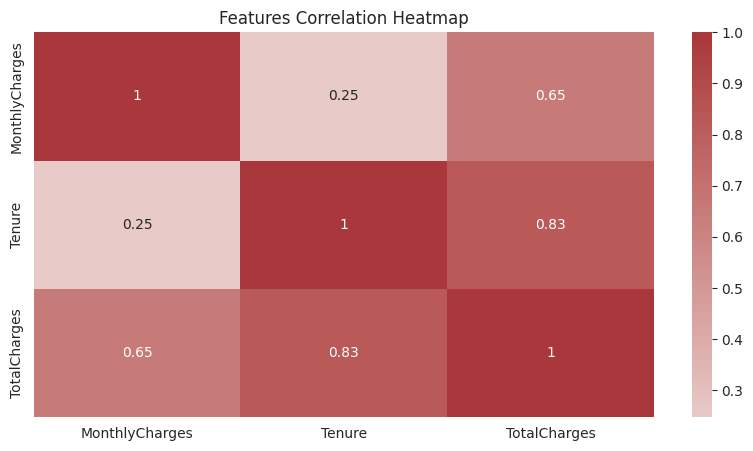

In [ ]:
#Get numerical columns except SeniorCitizen
numerical_cols = df_churn.select_dtypes(include=[np.number]).columns
numerical_cols = numerical_cols.difference(['SeniorCitizen'])

# Hitung correlation matrix tanpa SeniorCitizen
corr_matrix = df_churn[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap='vlag', center=0)
plt.title('Features Correlation Heatmap')
plt.show()

Catatan:
* Terdapat korelasi yang sangat tinggi antara TotalCharges dan Tenure (83%) --> dipilih salah satu: Tenure

##Data Prepocessing/ Data Cleaning
Column Name     |	DType  |	Cleaning Type|	Cause	| Rows |	Total rows effect
----------------|--------|---------------|--------|------|-------------------
customerID      |	object |	Drop kolom    |	Data tidak relevan|	all values|	NO
Gender          |	object |	Imputation = mode|	Missing value|	16|	No
SeniorCitizen   |	float64|	Convert data type: float --> int --> str|	categorical |	12|	No
|                |        |Imputation = mode  |	Missing value|	12|	No
Partner         |	object |	Imputation = mode|	Missing value|	16|	No
Dependents      |	object |	Imputation = mode|	Missing value|	19|	No
Tenure          |	float64|	Imputation = median|	Missing value|	17|	No
Contract        |	object |	Imputation = mode|	Missing value|	13|	No
PaperlessBilling|	object |	Imputation = mode|	Missing value|	13|	No
PaymentMethod   |	object |	Imputation = mode|	Missing value|	11|	No
MonthlyCharges  |	float64|	Imputation = median|	Missing value|	10|	No
TotalCharges    |	float64|	NO|	NO|	0|	No
Churn           |	object |	NO|	NO|	0|	No

* Berdasarkan feature correlation heatmap terdapat korelasi yang kuat antara TotalCharges dan Tenure, sehingga cukup diwakili salah satu, yakni: Tenure dan TotalCharges pada akhirnya akan di-drop.
* Kolom customerID akan dihapus.
* Tidak ada outliers --> tidak ada hapus data karena case outliers.

###Delete duplicate

In [ ]:
# Hapus data duplicate
x_dupl=df_churn.duplicated().sum()

print(f"Total duplicate: {x_dupl}\n")
print("Before")
print(f"Size: {df_churn.shape[0]}\n")

df_churn = df_churn.drop_duplicates() # drop duplicate

print("After")
print(f"Size: {df_churn.shape[0]}")

Total duplicate: 14

Before
Size: 7046

After
Size: 7032


###Drop column: customerID & TotalCharges

In [ ]:
# Drop kolom customerID
df_churn.drop(['customerID', 'TotalCharges'], axis=1, inplace=True)

###Convert categorical column: SeniorCitizen from float to object

In [ ]:
# Convert SeniorCitizen: float to integer to object
df_churn['SeniorCitizen'] = df_churn['SeniorCitizen'].astype('Int64')
df_churn['SeniorCitizen'] = df_churn['SeniorCitizen'].astype('object')

In [ ]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7031
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            7017 non-null   object 
 1   SeniorCitizen     7020 non-null   object 
 2   Partner           7016 non-null   object 
 3   Dependents        7013 non-null   object 
 4   Tenure            7015 non-null   float64
 5   Contract          7019 non-null   object 
 6   PaperlessBilling  7019 non-null   object 
 7   PaymentMethod     7021 non-null   object 
 8   MonthlyCharges    7022 non-null   float64
 9   Churn             7032 non-null   object 
dtypes: float64(2), object(8)
memory usage: 604.3+ KB


Catatan:
* Numerical: Tenure & MonthlyCharges, sisanya categorical.

##Test some models
* Logistic Regression
* Random Forest
* XGBoost
* LightGBM

In [ ]:
# Pisahkan data fitur dan target
X = df_churn.drop("Churn", axis=1)   # semua fitur
y = df_churn["Churn"]               # target (label churn: 0/1)

In [ ]:
X.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
0,Female,0,NaN,No,1.0,Month-to-month,Yes,Electronic check,29.85
1,Male,0,No,No,34.0,One year,No,Mailed check,56.95
2,Male,0,No,No,2.0,Month-to-month,Yes,Mailed check,53.85
3,Male,0,No,No,45.0,One year,No,Bank transfer (automatic),42.30
4,Female,0,No,No,2.0,Month-to-month,Yes,Electronic check,70.70


In [ ]:
y.head()

,Churn
0,No
1,No
2,Yes
3,No
4,Yes


###Splitting data: test, validation and test

In [ ]:
#Split data: train - test --> train - validation

# split data train:test = 80:20 dari X, y
X_train, X_test, y_train, y_test = train_test_split(
                                        X, y, test_size=0.2, random_state=42, stratify=y
                                    )

# split data train:val = 80:20 dari X_train, y_train
X_train, X_val, y_train, y_val = train_test_split(
                                        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
                                    )


In [ ]:
# Petakan label: Churn Yes=1 dan No=0
y_train = y_train.map({'Yes': 1, 'No': 0}).astype(int)
y_test = y_test.map({'Yes': 1, 'No': 0}).astype(int)
y_val = y_val.map({'Yes': 1, 'No': 0}).astype(int)

###Imputation

In [ ]:
# Cari median dan modus dari train, baru imputasi ke semuanya

#Imputasi Modus
cols_obj = X_train.columns[X_train.dtypes == 'object']
for col in cols_obj:
  train_mode = X_train[col].mode()[0]
  X_train[col] = X_train[col].fillna(train_mode)
  X_test[col] = X_test[col].fillna(train_mode)
  X_val[col] = X_val[col].fillna(train_mode)

# Imputasi Median
cols_num = X_train.select_dtypes(include=[np.number]).columns
for col in cols_num:
  train_median = X_train[col].median()
  X_train[col] = X_train[col].fillna(train_median)
  X_test[col] = X_test[col].fillna(train_median)
  X_val[col] = X_val[col].fillna(train_median)

In [ ]:
X_train.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
3805,Male,0,No,No,2.0,Month-to-month,Yes,Mailed check,54.45
5571,Male,0,No,No,48.0,One year,No,Bank transfer (automatic),19.95
3089,Female,0,No,No,39.0,One year,Yes,Credit card (automatic),58.60
5102,Female,0,No,No,8.0,Month-to-month,Yes,Electronic check,73.50
7021,Male,1,No,No,1.0,Month-to-month,Yes,Electronic check,75.75


In [ ]:
# staging dataset
stg_train = X_train.copy()
stg_val = X_val.copy()
stg_test = X_test.copy()

###General encoding: categorical 2 values

In [ ]:
# Berlaku untuk semua berbasis tree: selain logistic regression

# X_train
X_train['Gender'] = X_train['Gender'].map({'Male': 1, 'Female': 0})
X_train['Partner'] = X_train['Partner'].map({'Yes': 1, 'No': 0})
X_train['Dependents'] = X_train['Dependents'].map({'Yes': 1, 'No': 0})
X_train['PaperlessBilling'] = X_train['PaperlessBilling'].map({'Yes': 1, 'No': 0})
X_train["Contract"] = X_train["Contract"].astype("category").cat.codes
X_train["PaymentMethod"] = X_train["PaymentMethod"].astype("category").cat.codes

# X_val
X_val['Gender'] = X_val['Gender'].map({'Male': 1, 'Female': 0})
X_val['Partner'] = X_val['Partner'].map({'Yes': 1, 'No': 0})
X_val['Dependents'] = X_val['Dependents'].map({'Yes': 1, 'No': 0})
X_val['PaperlessBilling'] = X_val['PaperlessBilling'].map({'Yes': 1, 'No': 0})
X_val["Contract"] = X_val["Contract"].astype("category").cat.codes
X_val["PaymentMethod"] = X_val["PaymentMethod"].astype("category").cat.codes

# X_test
X_test['Gender'] = X_test['Gender'].map({'Male': 1, 'Female': 0})
X_test['Partner'] = X_test['Partner'].map({'Yes': 1, 'No': 0})
X_test['Dependents'] = X_test['Dependents'].map({'Yes': 1, 'No': 0})
X_test['PaperlessBilling'] = X_test['PaperlessBilling'].map({'Yes': 1, 'No': 0})
X_test["Contract"] = X_test["Contract"].astype("category").cat.codes
X_test["PaymentMethod"] = X_test["PaymentMethod"].astype("category").cat.codes

In [ ]:
X_train.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges
3805,1,0,0,0,2.0,0,1,3,54.45
5571,1,0,0,0,48.0,1,0,0,19.95
3089,0,0,0,0,39.0,1,1,1,58.60
5102,0,0,0,0,8.0,0,1,2,73.50
7021,1,1,0,0,1.0,0,1,2,75.75


In [ ]:
# Prepare data for logistic regression
# tidak termasuk model berbasis tree, sehingga perlu OHE
# model lainnya yang akan diuji cukup dengan label encoding
Xlr_train = X_train.copy()
Xlr_val = X_val.copy()
Xlr_test = X_test.copy()

# target
ylr_train = y_train.copy()
ylr_val = y_val.copy()
ylr_test = y_test.copy()

# train
Xlr_train['Contract']=stg_train['Contract']
Xlr_train['PaymentMethod']=stg_train['PaymentMethod']

# validation
Xlr_val['Contract']=stg_val['Contract']
Xlr_val['PaymentMethod']=stg_val['PaymentMethod']

# test
Xlr_test['Contract']=stg_test['Contract']
Xlr_test['PaymentMethod']=stg_test['PaymentMethod']

In [ ]:
ylr_train.head()

,Churn
3805,0
5571,0
3089,0
5102,0
7021,1


###OHE encoding: categorical > 2 values
* hanya untuk logistic regression

In [ ]:
# One-Hot Encoding Contract & PaymentMethod
# Tidak perlu sampai ke data test karena hanya baseline saja
Xlr_train = pd.get_dummies(Xlr_train,
                       columns=["Contract", "PaymentMethod"],
                       drop_first=True, # K-1
                       prefix={"Contract": "Ctr", "PaymentMethod": "Pay"}
                       )

Xlr_val = pd.get_dummies(Xlr_val,
                       columns=["Contract", "PaymentMethod"],
                       drop_first=True, # K-1
                       prefix={"Contract": "Ctr", "PaymentMethod": "Pay"}
                       )

In [ ]:
Xlr_train.head()

,Gender,SeniorCitizen,Partner,Dependents,Tenure,PaperlessBilling,MonthlyCharges,Ctr_One year,Ctr_Two year,Pay_Credit card (automatic),Pay_Electronic check,Pay_Mailed check
3805,1,0,0,0,2.0,1,54.45,False,False,False,False,True
5571,1,0,0,0,48.0,0,19.95,True,False,False,False,False
3089,0,0,0,0,39.0,1,58.60,True,False,True,False,False
5102,0,0,0,0,8.0,1,73.50,False,False,False,True,False
7021,1,1,0,0,1.0,1,75.75,False,False,False,True,False


###Performance test

In [ ]:
# Model berbasis tree vs Logistic Regression...
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42)
}

baseline_results = {}
for name, model in models.items():
    if name == "Logistic Regression":
      X_train_ = Xlr_train
      X_val_ = Xlr_val
      y_train_ = ylr_train
      y_val_ = ylr_val
    else:
      X_train_ = X_train
      X_val_ = X_val
      y_train_ = y_train
      y_val_ = y_val


    print(f"\nTraining {name}...")
    model.fit(X_train_, y_train_)
    y_pred = model.predict(X_val_) # Predict on validation set
    score = f1_score(y_val_, y_pred, pos_label=1) # F1-Score for class 1 (churn)

    print(f"F1-Score for {name}: {score:.4f}")
    print("Classification Report:\n", classification_report(y_val_, y_pred))
    baseline_results[name] = score


Training Logistic Regression...
F1-Score for Logistic Regression: 0.5313
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86       826
           1       0.61      0.47      0.53       299

    accuracy                           0.78      1125
   macro avg       0.72      0.68      0.69      1125
weighted avg       0.77      0.78      0.77      1125


Training Random Forest...
F1-Score for Random Forest: 0.5087
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       826
           1       0.60      0.44      0.51       299

    accuracy                           0.77      1125
   macro avg       0.71      0.67      0.68      1125
weighted avg       0.76      0.77      0.76      1125


Training XGBoost...
F1-Score for XGBoost: 0.5324
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87

###Performance Analysis

Model | F1-Score (Churn) | Analisis |
------|--------------------|---------
Logistic Regression | 0.5313 | Menunjukkan kinerja yang baik. Model ini memiliki keseimbangan precision-recall yang cukup baik untuk Churn.
Random Forest | 0.5087 | Model dengan kinerja terburuk. F1-Scorenya paling rendah. Meskipun bagus untuk Unchurn (0), model ini kurang mampu menangkap pola dari kelas minoritas (Churn).
XGBoost | 0.5324 | Model dengan performa terbaik (secara marginal). Meskipun precision-nya sedikit lebih rendah dari LightGBM, recall-nya lebih tinggi, yang menghasilkan F1-Score tertinggi. Ini berarti XGBoost lebih baik dalam "menemukan" sampel Churn.
LightGBM | 0.5259 | Kinerjanya sangat mirip dengan Logistic Regression. Memiliki precision tertinggi untuk Churn (0.62), tetapi recall-nya sangat rendah (0.46). Artinya, ketika LightGBM memprediksi suatu sampel sebagai Churn, prediksinya cukup bisa dipercaya, tetapi ia melewatkan banyak sekali sampel Churn yang sebenarnya (false negatives tinggi).

Kesimpulan:
* Kinerja model secara F1-score mirip, kecuali Random Forest yang paling buruk kinerjanya. Dan **XGBoost** sedikit lebih baik dibanding Logistic Regression. Tetapi untuk metric lainnya, Recall dan Precission, relatif tidak jauh selisihnya, jadi lebih stabil.
* Secara umum, semua model tidak mampu memprediksi Churn dengan baik.
* **Untuk selanjutnya akan diuji lebih jauh dengan hyperparameter, model XGBoost.**

##XGBoost
* Tidak ada proses scaling untuk model berbasis tree seperti XGBoost.

###Hyperparameter: Cross Valisation with Randomized

In [ ]:
# Definisikan model
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

# Definisikan ruang hyperparameter
param_dist = {
    "n_estimators": [200, 500, 800, 1200],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6, 8],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.5, 1],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.1, 1, 5, 10],
}

# Setup RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metric = f1-score, karena baik untuk data imbalance seperti
# kasus Churn dimana minoritas menjadi konsen.
scorer = make_scorer(f1_score)

rand_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,              # jumlah kombinasi dicoba
    scoring=scorer,
    cv=cv,
    verbose=3,
    random_state=42,
    n_jobs=-1
)

# Jalankan tuning
rand_search.fit(X_train, y_train)

print("Best Params   :", rand_search.best_params_)
print(f"Best CV Score : {rand_search.best_score_:.4f}")  # based on train

# Evaluasi di test set
best_model = rand_search.best_estimator_
y_pred = best_model.predict(X_test)

print(f"\nTest F1-Score : {f1_score(y_test, y_pred, pos_label=1):.4f}") # based on test
print("Classification Report:\n", classification_report(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params   : {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}
Best CV Score : 0.5867

Test F1-Score : 0.5727
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.90      0.87      1033
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



Catatan:
* Running bisa > 1 menit

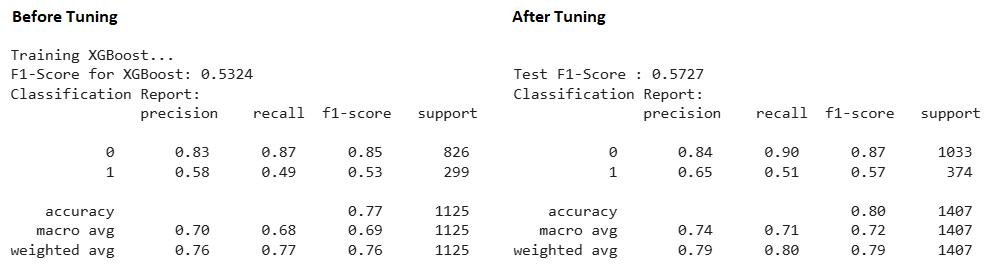

###Summary of model testing result

* Best score CV = 0.5867 (data train), sedangkan f1-score = 0.5727 (data test) sangat dekat, dengan selisih hanya sekitar 0.014 (1.4%). Ini menunjukkan bahwa model menggeneralisasi dengan baik dari data train ke data test.
* Berarti model tidak mengalami overfitting yang signifikan, yang merupakan indikator positif.
* Akurasi total: 80% --> 8 dari 10 prediksi benar. --> tetapi tidak mutlak untuk per jenis data (Churn/Unchurn), karena data tidak balance.
* Precision (Churn): 0.65 --> dari semua yang diprediksi churn, 65% memang benar churn.
* Recall (Churn): 0.51 --> model hanya menangkap 51% dari seluruh churn sebenarnya.
* F1-score (Churn): 0.57 --> keseimbangan antara precision dan recall masih moderat.

Hasil tuning:
* Setelah dilakukan tuning, maka model mengalami kenaikan kinerja yang cukup baik, secara keseluruhan score metric mengalami peningkatan. Misal f1-score (Churn), naik dari 0,53 menjadi 0,57 --> terdapat kenaikan kinerja sekitar 4%.

### Confusion Matrix

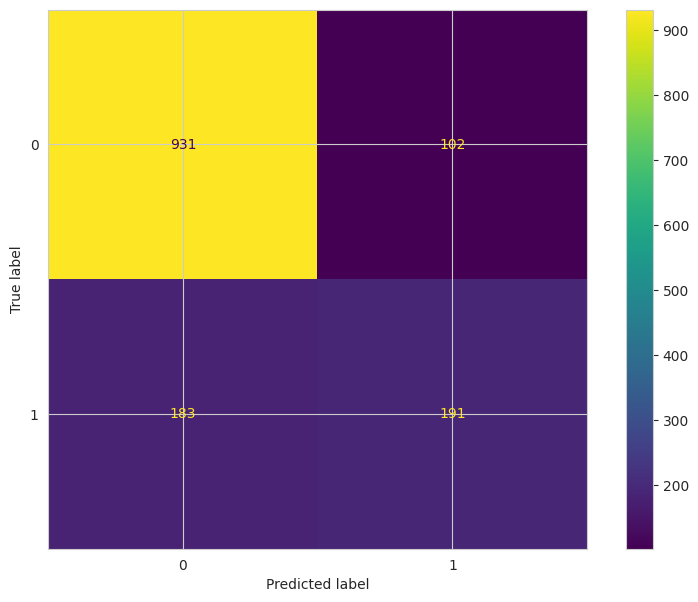

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(10,7))

cm = confusion_matrix(y_test, y_pred, labels=rand_search.best_estimator_.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=rand_search.best_estimator_.classes_)
disp.plot(ax=ax)
plt.show()

**Insight:**
* 931 pelanggan benar diprediksi “Unchurn”. (True Negatif)
* 191 pelanggan benar diprediksi “Churn”. (True Positive)
* 102 pelanggan salah diprediksi "Churn" padahal tidak (False Positive). --> bisa terjadi dilakukan biaya program retention yang tidak perlu
* 183 pelanggan gagal terdeteksi sebagai "Churn" (False Negative). --> pelanggan yang luput terdeksi Churn.

###Business Insight

* Risiko terbesar ada di recall churn (51%) --> Artinya model baru bisa memprediksi kira-kira separuh pelanggan churn. Masih ada 49% churner yang lolos tanpa terdeteksi. **Dalam konteks bisnis, ini berarti potensi kehilangan revenue (pelanggan) karena tidak semua pelanggan rawan churn teridentifikasi.**
* Precision 65% menunjukkan 35% prediksi salah. Model memprediksi 35% pelanggan akan Churn tetapi ternyata tidak. **Perusahaan yang sudah terlanjur mengeluarkan biaya untuk program retention, menjadi sia-sia.** --> Salah alokasi biaya.
* Trade-off cost:
  - Jika biaya kehilangan pelanggan lebih besar daripada biaya salah memberi insentif → sebaiknya fokus meningkatkan recall walaupun precision turun.
  - Jika biaya memberi insentif salah sasaran lebih tinggi → precision perlu ditingkatkan.

# *-- The End --*